# Feldman-Cousins confidence intervals

## Motivation: the NOMAD problem and empty intervals

This notebook presents the **Feldman-Cousins** method (Phys. Rev. D 57, 3873, 1998)
for constructing unified confidence intervals in Poisson counting experiments.

**Contents:**
1. The NOMAD problem: expecting background and seeing nothing
2. Classical Neyman intervals and their pathologies
3. The Feldman-Cousins ordering principle
4. Construction of the confidence belt
5. Numerical examples

## Setup

In [1]:
%matplotlib inline

import numpy  as np
import matplotlib.pyplot as plt
import scipy.stats as stats

import warnings
warnings.filterwarnings('ignore')

In [2]:
import os, sys
from pathlib import Path

_env = os.environ.get('FANAL_ROOT') or os.environ.get('USCFANALDIR')
if _env and Path(_env, 'data').is_dir():
    rootpath = str(Path(_env).resolve())
else:
    rootpath = str(next(p for p in [Path.cwd(), *Path.cwd().parents]
                        if (p / 'data').is_dir() and (p / 'ana').is_dir()))
if rootpath not in sys.path:
    sys.path.insert(0, rootpath)

import core.pltext  as pltext
import core.confint as confint
pltext.style()

print('Fanal root:', rootpath)

Fanal root: /Users/hernando/work/docencia/FPII-fanal/USC-FPII-Fanal


---
## 1. The NOMAD problem

The **NOMAD** experiment (CERN, search for $\nu_\mu \to \nu_\tau$ oscillations) expected to observe
$b = 3$ background events in its signal region.

**Question:** What happens if we observe $n = 0$ events?

With $b = 3$ expected background events, the probability of observing zero events is:

$$P(n=0 \mid \mu + b) = e^{-(\mu + b)}$$

For $\mu = 0$ (no signal): $P(0 \mid 3) = e^{-3} \approx 0.05$.

Unlikely, but not impossible. This scenario — expecting background and seeing nothing —
creates a serious problem with classical confidence intervals.

P(n=0 | mu=0, b=3) = 0.0498  (5.0%)


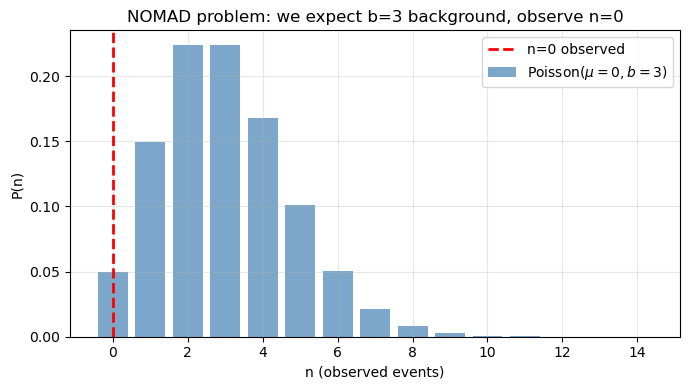

In [4]:
# Probability of observing n=0 with b=3 expected background events (no signal)
b_nomad = 3.0
p_zero  = stats.poisson.pmf(0, b_nomad)
print('P(n=0 | mu=0, b={:.0f}) = {:.4f}  ({:.1f}%)'.format(b_nomad, p_zero, 100*p_zero))

# Poisson distribution for b=3
ns_plot = np.arange(0, 15)
plt.figure(figsize=(7, 4))
plt.bar(ns_plot, stats.poisson.pmf(ns_plot, b_nomad), color='steelblue', alpha=0.7,
        label=r'Poisson($\mu=0, b=3$)')
plt.axvline(0, color='red', ls='--', lw=2, label='n=0 observed')
plt.xlabel('n (observed events)')
plt.ylabel('P(n)')
plt.title('NOMAD problem: we expect b=3 background, observe n=0')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

---
## 2. The problem with classical intervals

### Neyman construction for Poisson

For a Poisson process with mean $\mu + b$ (signal + background), the classical
**central** confidence interval at level $\alpha$ is constructed as follows:

For each true value of $\mu$, we find the acceptance interval $[n_1, n_2]$ such that:

$$P(n_1 \leq n \leq n_2 \mid \mu + b) \geq \alpha$$

splitting the remaining probability **equally** between both tails:

$$P(n < n_1 \mid \mu + b) \leq \frac{1-\alpha}{2}, \quad P(n > n_2 \mid \mu + b) \leq \frac{1-\alpha}{2}$$

The confidence interval for an observed $n$ is obtained by inverting this band:
the set of $\mu$ values whose acceptance intervals contain $n_{obs}$.

### The problem: empty intervals

With the central ordering, if $b = 3$ and we observe $n = 0$:

- The maximum likelihood estimator is $\hat{\mu} = n - b = 0 - 3 = -3$ (unphysical!)
- The central interval at 90% CL turns out to be **empty**: there is no $\mu \geq 0$
  whose acceptance interval includes $n = 0$

This is absurd: we observed real data and cannot say anything about $\mu$.

EMPTY INTERVAL! No mu >= 0 whose central acceptance band includes n=0


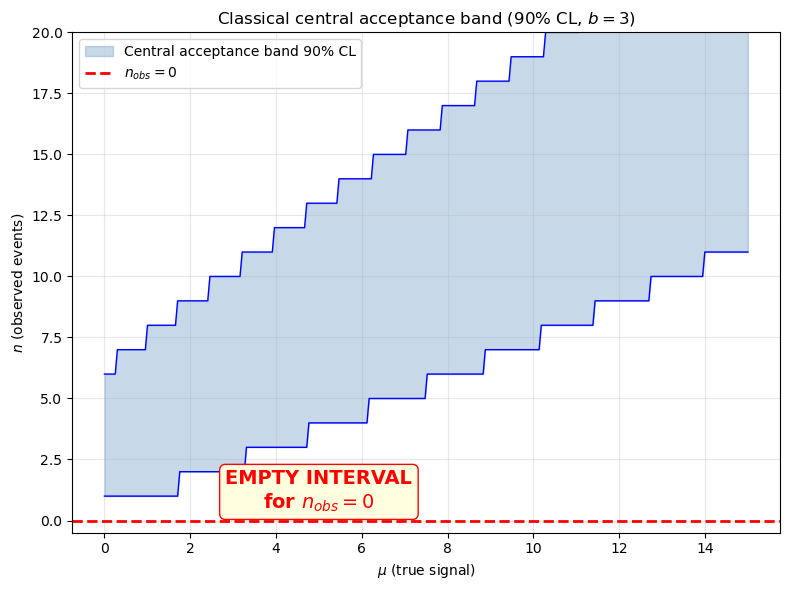

In [5]:
# Classical CENTRAL interval construction for Poisson with background
# Demonstration of the empty interval problem

def classical_central_interval(mu, bkg, cl=0.90, nmax=30):
    """Classical central acceptance interval for signal mu with background bkg.
    Splits probability (1-cl)/2 in each tail.
    Returns (n_low, n_high).
    """
    alpha = 1 - cl
    ns = np.arange(0, nmax + 1)
    pmf = stats.poisson.pmf(ns, mu + bkg)
    cdf = np.cumsum(pmf)
    
    # Lower tail: P(n < n_low) <= alpha/2
    n_low = 0
    while n_low < nmax and cdf[n_low] < alpha / 2:
        n_low += 1
    
    # Upper tail: P(n > n_high) <= alpha/2  =>  P(n <= n_high) >= 1 - alpha/2
    n_high = 0
    while n_high < nmax and cdf[n_high] < 1 - alpha / 2:
        n_high += 1
    
    return n_low, n_high

# Build the classical central band for b=3, 90% CL
bkg = 3.0
cl  = 0.90
mus_grid = np.linspace(0, 15, 300)

n_lows_classic = []
n_highs_classic = []
for mu in mus_grid:
    nl, nh = classical_central_interval(mu, bkg, cl)
    n_lows_classic.append(nl)
    n_highs_classic.append(nh)

n_lows_classic  = np.array(n_lows_classic)
n_highs_classic = np.array(n_highs_classic)

# Invert: for n_obs=0, find which mu values contain it
n_obs_test = 0
mask = (n_lows_classic <= n_obs_test) & (n_highs_classic >= n_obs_test)

plt.figure(figsize=(8, 6))
plt.fill_between(mus_grid, n_lows_classic, n_highs_classic, alpha=0.3, color='steelblue',
                 label='Central acceptance band 90% CL')
plt.plot(mus_grid, n_lows_classic, 'b-', lw=1)
plt.plot(mus_grid, n_highs_classic, 'b-', lw=1)
plt.axhline(n_obs_test, color='red', ls='--', lw=2, label='$n_{obs} = 0$')

if np.any(mask):
    mu_low = np.min(mus_grid[mask])
    mu_high = np.max(mus_grid[mask])
    plt.axvspan(mu_low, mu_high, alpha=0.3, color='red', label=r'CI: [{:.1f}, {:.1f}]'.format(mu_low, mu_high))
    print('Classical central interval for n_obs=0: [{:.2f}, {:.2f}]'.format(mu_low, mu_high))
else:
    plt.text(5, 0.5, 'EMPTY INTERVAL\nfor $n_{obs}=0$', fontsize=14, color='red',
             ha='center', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='red'))
    print('EMPTY INTERVAL! No mu >= 0 whose central acceptance band includes n=0')

plt.xlabel(r'$\mu$ (true signal)')
plt.ylabel(r'$n$ (observed events)')
plt.title(r'Classical central acceptance band (90% CL, $b={:.0f}$)'.format(bkg))
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.ylim(-0.5, 20)
plt.tight_layout()

### The flip-flopping problem

Beyond empty intervals, classical intervals suffer from **flip-flopping**:

- If the experimenter observes $n$ large (relative to $b$), they report a **central** two-sided interval for $\mu$.
- If they observe $n$ small (compatible with or below $b$), they switch to a one-sided **upper limit**.

This *a posteriori* decision (based on the data) **violates frequentist coverage**.
The 90% confidence level no longer means the interval contains the true value
90% of the time, because the construction rule changes depending on the outcome.

| Scenario | Classical decision | Problem |
|-----------|-----------------|----------|
| $n \gg b$ | Two-sided interval | OK |
| $n \approx b$ | Two-sided or upper limit? | Ambiguity |
| $n < b$ | Upper limit | Under-coverage |
| $n = 0, b > 0$ | Upper limit... or empty? | Empty interval |

**Feldman and Cousins solve both problems** with a single procedure that automatically
transitions between upper limits and two-sided intervals.

---
## 3. The Feldman-Cousins ordering method

### Key idea: ordering by likelihood ratio

The Neyman construction requires choosing **which values of $n$ to include first** in the
acceptance interval of each $\mu$. The classical central ordering splits the tails equally.
Feldman-Cousins proposes a different criterion: **ordering by the likelihood ratio**.

For each possible observation $n$, compute:

$$R(n) = \frac{P(n \mid \mu)}{P(n \mid \hat{\mu}_{\text{best}})}$$

where:
- $P(n \mid \mu) = \frac{(\mu + b)^n \, e^{-(\mu+b)}}{n!}$ is the Poisson probability of observing $n$ given $\mu$ and $b$
- $\hat{\mu}_{\text{best}} = \max(n - b, \, 0)$ is the **best physical estimator** of $\mu$ given $n$
  (constrained to $\mu \geq 0$, since the signal cannot be negative)
- $P(n \mid \hat{\mu}_{\text{best}})$ is the probability evaluated at the best fit

Equivalently, we use the test statistic:

$$t(n) = -2 \ln R(n) = -2 \left[\ln P(n \mid \mu) - \ln P(n \mid \hat{\mu}_{\text{best}})\right]$$

**Values of $n$ with the smallest $t$ (largest $R$) are included first.**

### Step-by-step algorithm

For a fixed value of $\mu$ and background $b$, at confidence level CL:

1. For each $n = 0, 1, 2, \ldots, n_{\max}$:
   - Compute $\hat{\mu}_{\text{best}}(n) = \max(n - b, 0)$
   - Compute $R(n) = P(n \mid \mu + b) \,/\, P(n \mid \hat{\mu}_{\text{best}} + b)$
   
2. Sort the values of $n$ from largest to smallest $R$ (equivalently, from smallest to largest $t$)

3. Include values of $n$ in that order, accumulating $P(n \mid \mu + b)$, until the cumulative probability reaches CL

4. The acceptance interval is $[n_{\min}, n_{\max}]$ of the included values

5. Repeat for each $\mu$ on a fine grid

6. **Invert**: for a given $n_{\text{obs}}$, the confidence interval is the set of $\mu$ values whose acceptance intervals contain $n_{\text{obs}}$

### Worked example: FC ordering for $\mu = 1$, $b = 3$

Let us walk through step by step how FC selects which values of $n$ to include in the acceptance interval.

In [6]:
# Step-by-step FC ordering example
mu_example = 1.0
bkg        = 3.0
cl         = 0.90
ns         = np.arange(0, 15)

# Step 1: for each n, compute mu_best and the probabilities
mu_best = np.maximum(ns - bkg, 0.)      # physical estimator
p_mu    = stats.poisson.pmf(ns, mu_example + bkg)  # P(n | mu + b)
p_best  = stats.poisson.pmf(ns, mu_best + bkg)     # P(n | mu_best + b)

# Likelihood ratio and test statistic t
R = p_mu / p_best
t = -2 * (np.log(p_mu + 1e-300) - np.log(p_best + 1e-300))

# Table with all values
print('  n  | mu_best |  P(n|mu+b) | P(n|best)  |    R     |    t')
print('-----|---------|------------|------------|----------|--------')
for i, n in enumerate(ns):
    print(' {:2d}  |  {:4.1f}   | {:.6f}  | {:.6f}  | {:.4f}  | {:6.3f}'.format(
        n, mu_best[i], p_mu[i], p_best[i], R[i], t[i]))

  n  | mu_best |  P(n|mu+b) | P(n|best)  |    R     |    t
-----|---------|------------|------------|----------|--------
  0  |   0.0   | 0.018316  | 0.049787  | 0.3679  |  2.000
  1  |   0.0   | 0.073263  | 0.149361  | 0.4905  |  1.425
  2  |   0.0   | 0.146525  | 0.224042  | 0.6540  |  0.849
  3  |   0.0   | 0.195367  | 0.224042  | 0.8720  |  0.274
  4  |   1.0   | 0.195367  | 0.195367  | 1.0000  | -0.000
  5  |   2.0   | 0.156293  | 0.175467  | 0.8907  |  0.231
  6  |   3.0   | 0.104196  | 0.160623  | 0.6487  |  0.866
  7  |   4.0   | 0.059540  | 0.149003  | 0.3996  |  1.835
  8  |   5.0   | 0.029770  | 0.139587  | 0.2133  |  3.090
  9  |   6.0   | 0.013231  | 0.131756  | 0.1004  |  4.597
 10  |   7.0   | 0.005292  | 0.125110  | 0.0423  |  6.326
 11  |   8.0   | 0.001925  | 0.119378  | 0.0161  |  8.255
 12  |   9.0   | 0.000642  | 0.114368  | 0.0056  | 10.367
 13  |  10.0   | 0.000197  | 0.109940  | 0.0018  | 12.645
 14  |  11.0   | 0.000056  | 0.105989  | 0.0005  | 15.077


In [7]:
# Steps 2-3: Sort by t (smallest first) and accumulate probability
order = np.argsort(t)
cum_prob = 0.
included = []

print('FC inclusion order (mu={:.1f}, b={:.1f}, CL={:.0f}%):'.format(mu_example, bkg, 100*cl))
print('  step |  n  |    t   |  P(n|mu+b)  |  cumulative P | included')
print('-------|-----|--------|-------------|---------------|----------')
for step, idx in enumerate(order):
    cum_prob += p_mu[idx]
    if len(included) == 0 or (cum_prob - p_mu[idx]) < cl:
        included.append(ns[idx])
        mark = '<--'
    else:
        included.append(ns[idx])
        mark = '<-- (reaches CL)'
        
    print('   {:2d}  | {:2d}  | {:5.3f} |  {:.6f}   |   {:.6f}     | {:s}'.format(
        step, ns[idx], t[idx], p_mu[idx], cum_prob, mark))
    
    if cum_prob >= cl:
        break

print()
print('FC acceptance interval: [{:d}, {:d}]'.format(min(included), max(included)))
print('Cumulative probability: {:.4f} >= {:.2f}'.format(cum_prob, cl))

FC inclusion order (mu=1.0, b=3.0, CL=90%):
  step |  n  |    t   |  P(n|mu+b)  |  cumulative P | included
-------|-----|--------|-------------|---------------|----------
    0  |  4  | -0.000 |  0.195367   |   0.195367     | <--
    1  |  5  | 0.231 |  0.156293   |   0.351660     | <--
    2  |  3  | 0.274 |  0.195367   |   0.547027     | <--
    3  |  2  | 0.849 |  0.146525   |   0.693552     | <--
    4  |  6  | 0.866 |  0.104196   |   0.797748     | <--
    5  |  1  | 1.425 |  0.073263   |   0.871010     | <--
    6  |  7  | 1.835 |  0.059540   |   0.930551     | <--

FC acceptance interval: [1, 7]
Cumulative probability: 0.9306 >= 0.90


**Key observation:** Note that for $n < b$ (e.g. $n = 0, 1, 2$), the estimator
$\hat\mu_\text{best} = 0$ (it saturates at the physical boundary), and the ratio $R$ is not
necessarily small. This allows $n=0$ **to be included** in the acceptance interval of small
values of $\mu$, resolving the empty interval problem.

---
## 4. Building the full FC confidence belt

FC 90% CI for n_obs=0, b=3: mu in [0.00, 0.90]
  -> Upper limit: mu < 0.90
  n_obs = 0: mu in [0.00, 0.90]
  n_obs = 1: mu in [0.00, 1.86]
  n_obs = 2: mu in [0.00, 3.01]
  n_obs = 3: mu in [0.00, 4.41]
  n_obs = 5: mu in [0.00, 6.97]
  n_obs = 8: mu in [1.56, 10.99]


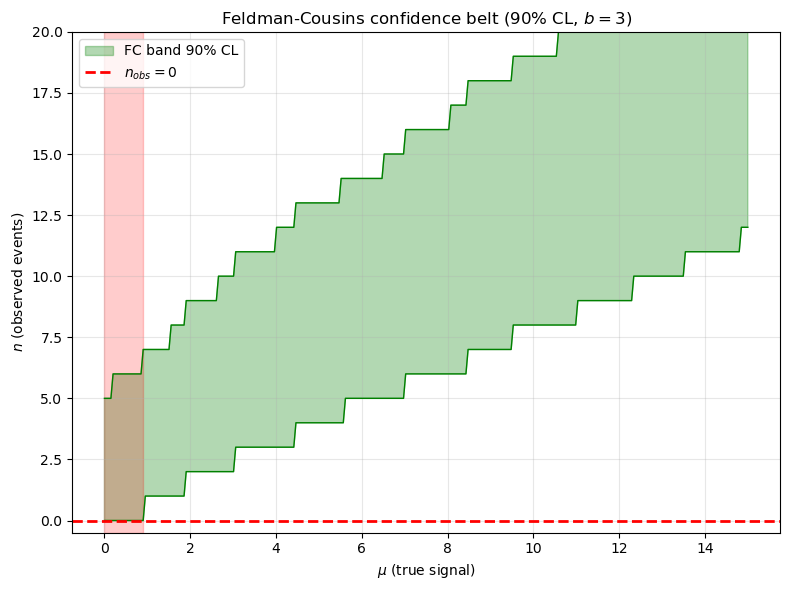

In [8]:
# Build the FC confidence belt for the NOMAD case: b=3, 90% CL
bkg = 3.0
cl  = 0.90
mus = np.linspace(0., 15., 300)

# Use the confint module from the project
n0s, n1s = confint.fc_confband(mus, bkg, cl=cl)

# Also build the confidence interval function
fc_90 = confint.get_fc_confinterval(mus, bkg, cl=cl)

plt.figure(figsize=(8, 6))

# FC acceptance band
plt.fill_between(mus, n0s, n1s, alpha=0.3, color='green',
                 label='FC band 90% CL')
plt.plot(mus, n0s, 'g-', lw=1)
plt.plot(mus, n1s, 'g-', lw=1)

# Case n_obs = 0
plt.axhline(0, color='red', ls='--', lw=2, label='$n_{obs} = 0$')
ci_0 = fc_90(0)
plt.axvspan(ci_0[0], ci_0[1], alpha=0.2, color='red')

print('FC 90% CI for n_obs=0, b={:.0f}: mu in [{:.2f}, {:.2f}]'.format(bkg, *ci_0))
print('  -> Upper limit: mu < {:.2f}'.format(ci_0[1]))

# Also show n_obs = 1, 2, 3
for n_test in [0, 1, 2, 3, 5, 8]:
    ci = fc_90(n_test)
    print('  n_obs = {:d}: mu in [{:.2f}, {:.2f}]'.format(n_test, *ci))

plt.xlabel(r'$\mu$ (true signal)')
plt.ylabel(r'$n$ (observed events)')
plt.title(r'Feldman-Cousins confidence belt (90% CL, $b={:.0f}$)'.format(bkg))
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.ylim(-0.5, 20)
plt.tight_layout()

### Comparison: classical central vs Feldman-Cousins

Let us overlay both bands to understand the difference.

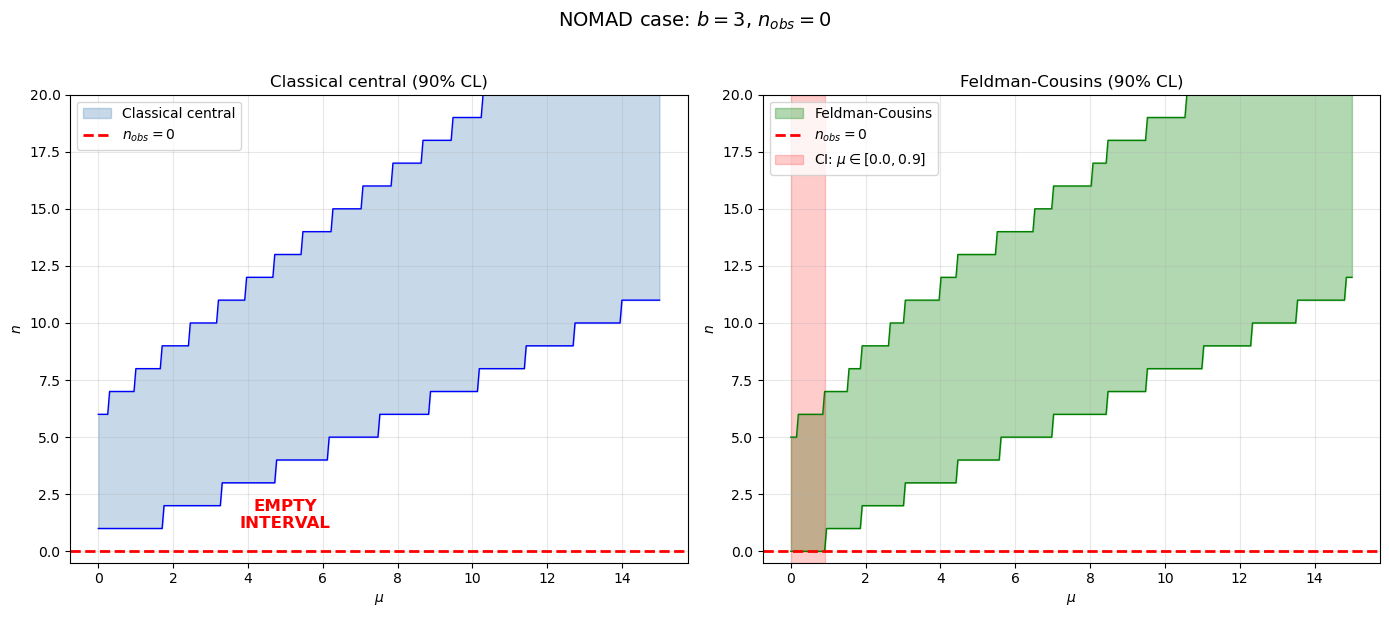

In [9]:
# Side-by-side comparison of both bands
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: Classical central
ax = axes[0]
ax.fill_between(mus_grid, n_lows_classic, n_highs_classic, alpha=0.3, color='steelblue',
                label='Classical central')
ax.plot(mus_grid, n_lows_classic, 'b-', lw=1)
ax.plot(mus_grid, n_highs_classic, 'b-', lw=1)
ax.axhline(0, color='red', ls='--', lw=2, label='$n_{obs} = 0$')
ax.set_xlabel(r'$\mu$'); ax.set_ylabel(r'$n$')
ax.set_title('Classical central (90% CL)')
ax.set_ylim(-0.5, 20); ax.legend(loc='upper left'); ax.grid(alpha=0.3)
ax.text(5, 1, 'EMPTY\nINTERVAL', fontsize=12, color='red', ha='center', fontweight='bold')

# Right panel: Feldman-Cousins
ax = axes[1]
ax.fill_between(mus, n0s, n1s, alpha=0.3, color='green', label='Feldman-Cousins')
ax.plot(mus, n0s, 'g-', lw=1)
ax.plot(mus, n1s, 'g-', lw=1)
ax.axhline(0, color='red', ls='--', lw=2, label='$n_{obs} = 0$')
ci_0 = fc_90(0)
ax.axvspan(ci_0[0], ci_0[1], alpha=0.2, color='red',
           label=r'CI: $\mu \in [{:.1f}, {:.1f}]$'.format(*ci_0))
ax.set_xlabel(r'$\mu$'); ax.set_ylabel(r'$n$')
ax.set_title('Feldman-Cousins (90% CL)')
ax.set_ylim(-0.5, 20); ax.legend(loc='upper left'); ax.grid(alpha=0.3)

plt.suptitle(r'NOMAD case: $b = {:.0f}$, $n_{{obs}} = 0$'.format(bkg), fontsize=14, y=1.02)
plt.tight_layout()

---
## 5. Automatic transition: upper limit ↔ two-sided interval

One of the main virtues of FC is that it **does not require deciding a priori** whether to report
an upper limit or a two-sided interval. The transition occurs naturally:

- For **small** $n_\text{obs}$ (less than or close to $b$): the FC interval is asymmetric
  and starts at $\mu = 0$ -- it acts as an **upper limit**
- For **large** $n_\text{obs}$ (well above $b$): the FC interval centres around
  $\hat\mu = n - b$ -- it acts as a **two-sided interval**

This solves the *flip-flopping* problem: the same procedure, applied blindly before
seeing the data, produces the correct type of interval.

Transition from upper limit to two-sided interval:
  n= 0: mu in [ 0.00,  0.95]  (Upper limit)
  n= 1: mu in [ 0.00,  1.85]  (Upper limit)
  n= 2: mu in [ 0.00,  3.01]  (Upper limit)
  n= 3: mu in [ 0.00,  4.41]  (Upper limit)
  n= 4: mu in [ 0.00,  5.56]  (Upper limit)
  n= 5: mu in [ 0.00,  6.97]  (Upper limit)
  n= 6: mu in [ 0.20,  8.42]  (Two-sided)
  n= 7: mu in [ 0.90,  9.52]  (Two-sided)
  n= 8: mu in [ 1.55, 10.98]  (Two-sided)
  n= 9: mu in [ 1.90, 12.28]  (Two-sided)
  n=10: mu in [ 2.66, 13.48]  (Two-sided)
  n=11: mu in [ 3.06, 14.79]  (Two-sided)
  n=12: mu in [ 4.01, 15.99]  (Two-sided)
  n=13: mu in [ 4.46, 17.04]  (Two-sided)
  n=14: mu in [ 5.51, 18.50]  (Two-sided)
  n=15: mu in [ 6.52, 19.50]  (Two-sided)


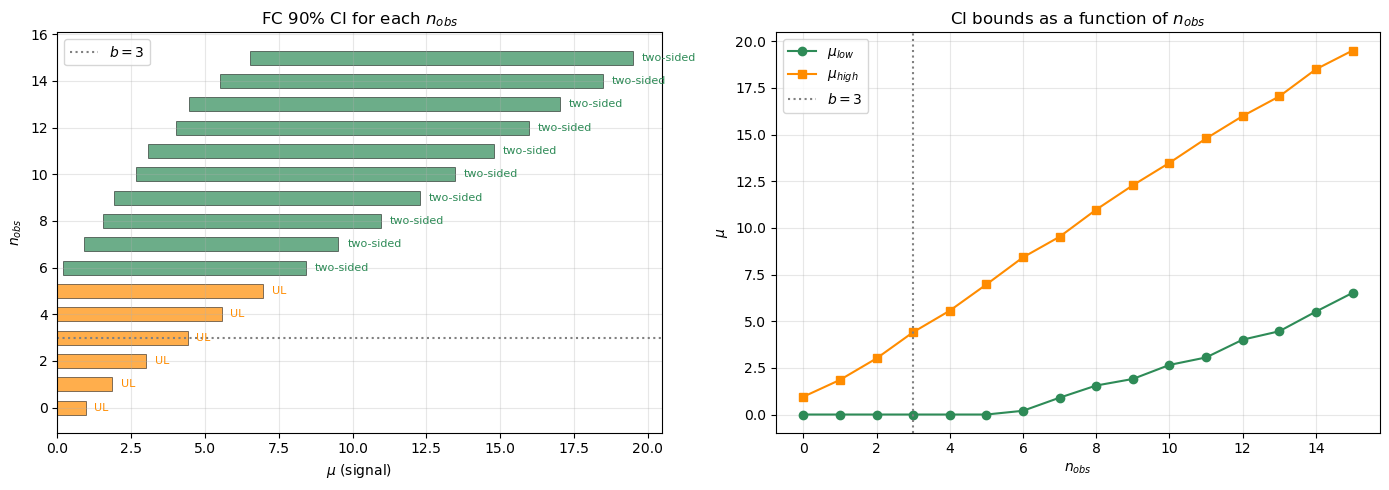

In [10]:
# Demonstration of the upper limit → two-sided interval transition
bkg = 3.0
mus = np.linspace(0., 20., 400)
fc_90 = confint.get_fc_confinterval(mus, bkg, cl=0.90)

ns_demo = np.arange(0, 16)
cis = [fc_90(n) for n in ns_demo]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: FC intervals for each n_obs
ax = axes[0]
for i, n in enumerate(ns_demo):
    ci = cis[i]
    color = 'darkorange' if ci[0] == 0 else 'seagreen'
    tipo  = 'UL' if ci[0] == 0 else 'two-sided'
    ax.barh(n, ci[1] - ci[0], left=ci[0], height=0.6, color=color, alpha=0.7,
            edgecolor='k', lw=0.5)
    ax.text(ci[1] + 0.3, n, tipo, va='center', fontsize=8, color=color)

ax.axhline(bkg, color='gray', ls=':', lw=1.5, label='$b = {:.0f}$'.format(bkg))
ax.set_ylabel(r'$n_{obs}$')
ax.set_xlabel(r'$\mu$ (signal)')
ax.set_title('FC 90% CI for each $n_{obs}$')
ax.legend()
ax.grid(alpha=0.3)

# Right panel: interval bounds
ax2 = axes[1]
mu_lows  = [ci[0] for ci in cis]
mu_highs = [ci[1] for ci in cis]
ax2.plot(ns_demo, mu_lows, 'o-', color='seagreen', label=r'$\mu_{low}$')
ax2.plot(ns_demo, mu_highs, 's-', color='darkorange', label=r'$\mu_{high}$')
ax2.axvline(bkg, color='gray', ls=':', lw=1.5, label='$b = {:.0f}$'.format(bkg))
ax2.set_xlabel(r'$n_{obs}$')
ax2.set_ylabel(r'$\mu$')
ax2.set_title(r'CI bounds as a function of $n_{obs}$')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()

print('Transition from upper limit to two-sided interval:')
for n in ns_demo:
    ci = fc_90(n)
    tipo = 'Upper limit' if ci[0] == 0 else 'Two-sided'
    print('  n={:2d}: mu in [{:5.2f}, {:5.2f}]  ({:s})'.format(n, ci[0], ci[1], tipo))

---
## 6. Effect of background on the FC belt

How does the confidence belt change with the background level? Let us compare $b = 0$, $b = 3$, and $b = 10$.

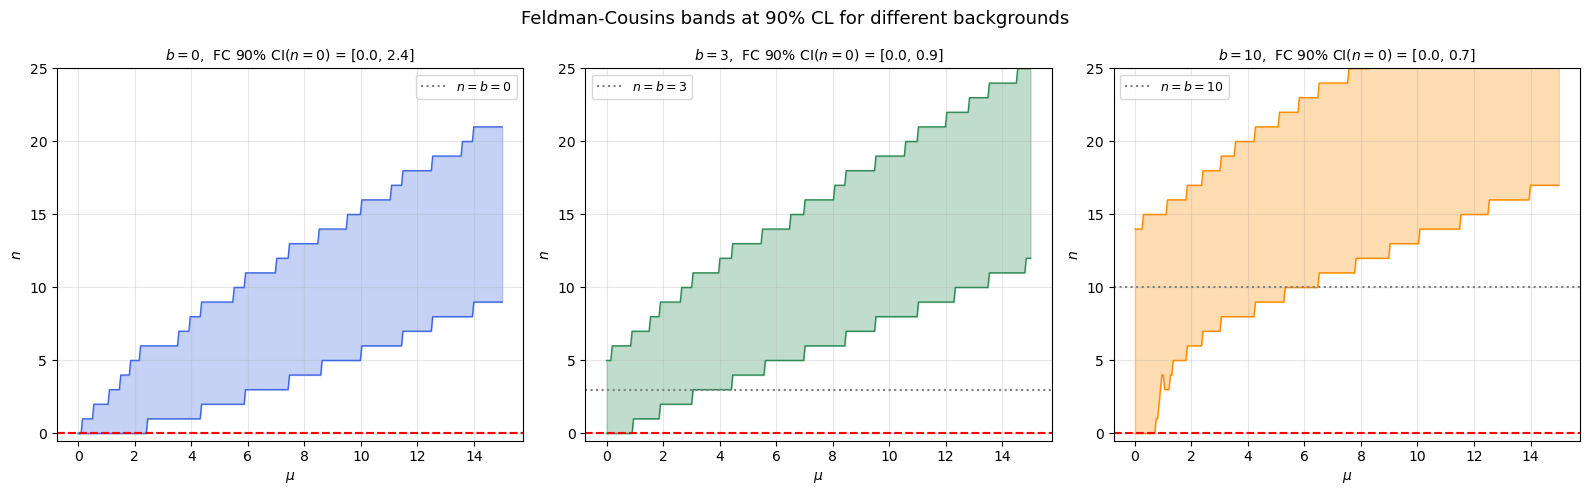

In [11]:
# Comparison of FC bands for different background levels
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bkgs   = [0., 3., 10.]
colors = ['royalblue', 'seagreen', 'darkorange']
mus_fine = np.linspace(0., 15., 300)

for ax, b, col in zip(axes, bkgs, colors):
    fc = confint.get_fc_confinterval(mus_fine, b, cl=0.90)
    n0, n1 = confint.fc_confband(mus_fine, b, cl=0.90)
    
    ax.fill_between(mus_fine, n0, n1, alpha=0.3, color=col)
    ax.plot(mus_fine, n0, '-', color=col, lw=1)
    ax.plot(mus_fine, n1, '-', color=col, lw=1)
    
    # Show n=b line
    ax.axhline(b, color='gray', ls=':', label='$n = b = {:.0f}$'.format(b))
    
    # CI for n_obs = 0
    ci = fc(0)
    ax.axhline(0, color='red', ls='--', lw=1.5)
    ax.set_title('$b = {:.0f}$,  FC 90% CI($n=0$) = [{:.1f}, {:.1f}]'.format(b, *ci), fontsize=10)
    ax.set_xlabel(r'$\mu$')
    ax.set_ylabel(r'$n$')
    ax.set_ylim(-0.5, 25)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Feldman-Cousins bands at 90% CL for different backgrounds', fontsize=13)
plt.tight_layout()

---
## 7. Comparison of confidence levels

Let us see how the FC intervals change at 68%, 90%, and 95% CL for the $b = 3$ case.


Summary for n_obs = 0, b = 3:
  95% CL: mu in [0.00, 1.61]  (UL = 1.61)
  90% CL: mu in [0.00, 0.90]  (UL = 0.90)
  68% CL: mu in [0.00, 0.10]  (UL = 0.10)


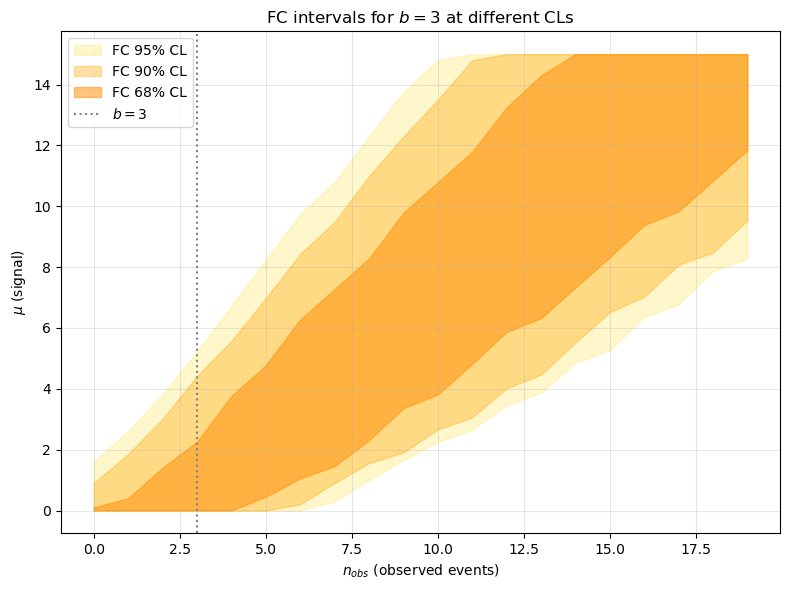

In [12]:
# FC bands at different confidence levels
bkg = 3.0
mus = np.linspace(0., 15., 300)
ns_range = np.arange(0, 20)

cls    = [0.95, 0.90, 0.68]
alphas = [0.2,  0.35, 0.5]
colors = ['gold', 'orange', 'darkorange']

plt.figure(figsize=(8, 6))
for cl, alpha, col in zip(cls, alphas, colors):
    fc = confint.get_fc_confinterval(mus, bkg, cl=cl)
    ys = fc(ns_range)
    plt.fill_between(ns_range, ys[0], ys[1], alpha=alpha, color=col,
                     label='FC {:.0f}% CL'.format(100*cl))

plt.axvline(bkg, color='gray', ls=':', label='$b = {:.0f}$'.format(bkg))
plt.xlabel(r'$n_{obs}$ (observed events)')
plt.ylabel(r'$\mu$ (signal)')
plt.title(r'FC intervals for $b = {:.0f}$ at different CLs'.format(bkg))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Summary table for n_obs = 0
print('\nSummary for n_obs = 0, b = {:.0f}:'.format(bkg))
for cl in cls:
    fc = confint.get_fc_confinterval(mus, bkg, cl=cl)
    ci = fc(0)
    print('  {:2.0f}% CL: mu in [{:.2f}, {:.2f}]  (UL = {:.2f})'.format(100*cl, ci[0], ci[1], ci[1]))

---
## Summary

| Aspect | Classical central interval | Feldman-Cousins |
|---------|--------------------------|-----------------|
| Ordering | Equal tails $(1-\alpha)/2$ | Likelihood ratio $R(n)$ |
| $n \ll b$ | Empty interval | Upper limit (valid) |
| $n \gg b$ | Two-sided interval | Two-sided interval |
| Prior decision | Must choose UL vs two-sided | Automatic |
| Coverage | Violated by *flip-flopping* | Guaranteed by construction |
| Physical constraint $\mu \geq 0$ | Not incorporated | Built in via $\hat\mu_{\text{best}}$ |

**Reference:** G.J. Feldman and R.D. Cousins, *"Unified approach to the classical statistical
analysis of small signals"*, Phys. Rev. D 57, 3873 (1998). [arXiv:physics/9711021]